## **Overview** 
These notebook covers Phases 2 and 3 of the dissertation : Dataset Collection, Exploratory Data Analysis, Data Cleaning, and Feature Engineering. 

Its purpose is to deeply understand the raw CRM data before any modelling begins, identify data quality issues, discover conversion patterns, and engineer meaningful features that will power the machine learning models in Phase 4

## Library Imports and Data Loading


### What Was Done
- Imported required Python libraries
- Loaded dataset into pandas DataFrame
- Checked dataset shape and column names

### Why This Was Done
- Explain purpose of each library
- Importance of validating dataset loading
- Importance of confirming structure before analysis

### What It Showed
- Total rows and columns
- Dataset validation confirmation

In [1]:
# ============================================================
# CELL 1 — Imports & Data Loading
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 5)

# Load dataset
df = pd.read_csv('../data/Leads.csv')

# Quick sanity check
print("Shape:", df.shape)
print("\nFirst look at columns:")
print(df.columns.tolist())

Shape: (9240, 37)

First look at columns:
['Prospect ID', 'Lead Number', 'Lead Origin', 'Lead Source', 'Do Not Email', 'Do Not Call', 'Converted', 'TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit', 'Last Activity', 'Country', 'Specialization', 'How did you hear about X Education', 'What is your current occupation', 'What matters most to you in choosing a course', 'Search', 'Magazine', 'Newspaper Article', 'X Education Forums', 'Newspaper', 'Digital Advertisement', 'Through Recommendations', 'Receive More Updates About Our Courses', 'Tags', 'Lead Quality', 'Update me on Supply Chain Content', 'Get updates on DM Content', 'Lead Profile', 'City', 'Asymmetrique Activity Index', 'Asymmetrique Profile Index', 'Asymmetrique Activity Score', 'Asymmetrique Profile Score', 'I agree to pay the amount through cheque', 'A free copy of Mastering The Interview', 'Last Notable Activity']


## Basic Data Overview

### What Was Done
- Checked target variable distribution
- Performed missing value analysis
- Audited data types

### Why This Was Done

#### *Target Variable Analysis*
- Importance of class balance
- Impact on machine learning models

#### *Missing Value Analysis*
- Importance of identifying incomplete data
- Impact on cleaning strategy

#### *Data Type Audit*
- Need for numerical input in ML models
- Importance of identifying categorical columns

### What It Showed

#### *Target Variable Distribution*
- Class counts
- Percentages
- Class imbalance interpretation

#### *Missing Values*
- Columns with highest missing values
- Identification of problematic columns

#### *Data Types*
- Number of object columns
- Number of numerical columns

In [2]:
# ============================================================
# CELL 2 — Basic Data Overview
# ============================================================

print("=== SHAPE ===")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n=== TARGET VARIABLE DISTRIBUTION ===")
print(df['Converted'].value_counts())
print(f"\nConversion Rate: {df['Converted'].mean()*100:.2f}%")

print("\n=== MISSING VALUES (Top 15) ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False).head(15))

print("\n=== DATA TYPES ===")
print(df.dtypes.value_counts())

=== SHAPE ===
Rows: 9240, Columns: 37

=== TARGET VARIABLE DISTRIBUTION ===
Converted
0    5679
1    3561
Name: count, dtype: int64

Conversion Rate: 38.54%

=== MISSING VALUES (Top 15) ===
                                               Missing Count  Missing %
Lead Quality                                            4767  51.590909
Asymmetrique Profile Score                              4218  45.649351
Asymmetrique Activity Score                             4218  45.649351
Asymmetrique Profile Index                              4218  45.649351
Asymmetrique Activity Index                             4218  45.649351
Tags                                                    3353  36.287879
Lead Profile                                            2709  29.318182
What matters most to you in choosing a course           2709  29.318182
What is your current occupation                         2690  29.112554
Country                                                 2461  26.634199
How did you hear a

## Visual Overview

### What Was Done
- Created target distribution chart
- Created missing value chart
- Created lead source frequency chart

### Why This Was Done
- Importance of visual analysis
- Dissertation-ready visualisations
- Easier identification of patterns

### What It Showed

#### *Target Distribution*
- Visual interpretation of imbalance

#### *Missing Values*
- Most problematic columns visually identified

#### *Lead Sources*
- Most common lead acquisition channels

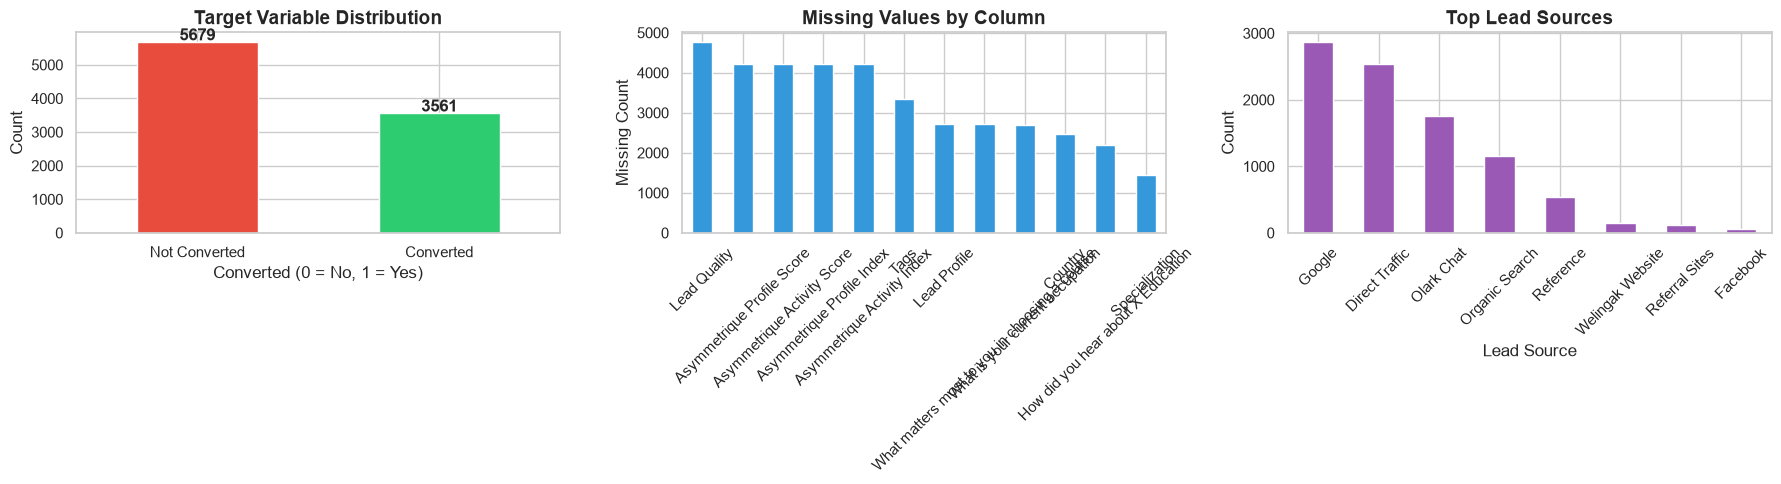

Chart saved to outputs folder.


In [3]:
# ============================================================
# CELL 3 — Visual Overview
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1 - Class distribution
df['Converted'].value_counts().plot(
    kind='bar', ax=axes[0], color=['#E74C3C', '#2ECC71'], edgecolor='white'
)
axes[0].set_title('Target Variable Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Converted (0 = No, 1 = Yes)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Not Converted', 'Converted'], rotation=0)
for i, v in enumerate(df['Converted'].value_counts()):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Plot 2 - Missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False).head(12)
missing.plot(kind='bar', ax=axes[1], color='#3498DB', edgecolor='white')
axes[1].set_title('Missing Values by Column', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Missing Count')
axes[1].tick_params(axis='x', rotation=45)

# Plot 3 - Lead Source distribution
df['Lead Source'].value_counts().head(8).plot(
    kind='bar', ax=axes[2], color='#9B59B6', edgecolor='white'
)
axes[2].set_title('Top Lead Sources', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../outputs/01_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to outputs folder.")

## Conversion Analysis by Key CRM Fields

### What Was Done
- Analysed conversion rates by:
  - Lead Source
  - Lead Origin
  - Website Time
  - Total Visits

### Why This Was Done
- Identify predictive signal
- Validate feature usefulness
- Support feature engineering decisions

### What It Showed

#### *Conversion by Lead Source*
- High-converting sources
- High-volume vs high-conversion insight

#### *Conversion by Lead Origin*
- Behavioural intent analysis

#### *Time Spent on Website*
- Comparison between converted and non-converted leads
- Strong behavioural predictor insight

#### *Total Visits*
- Weak predictor observation
- Outlier discussion


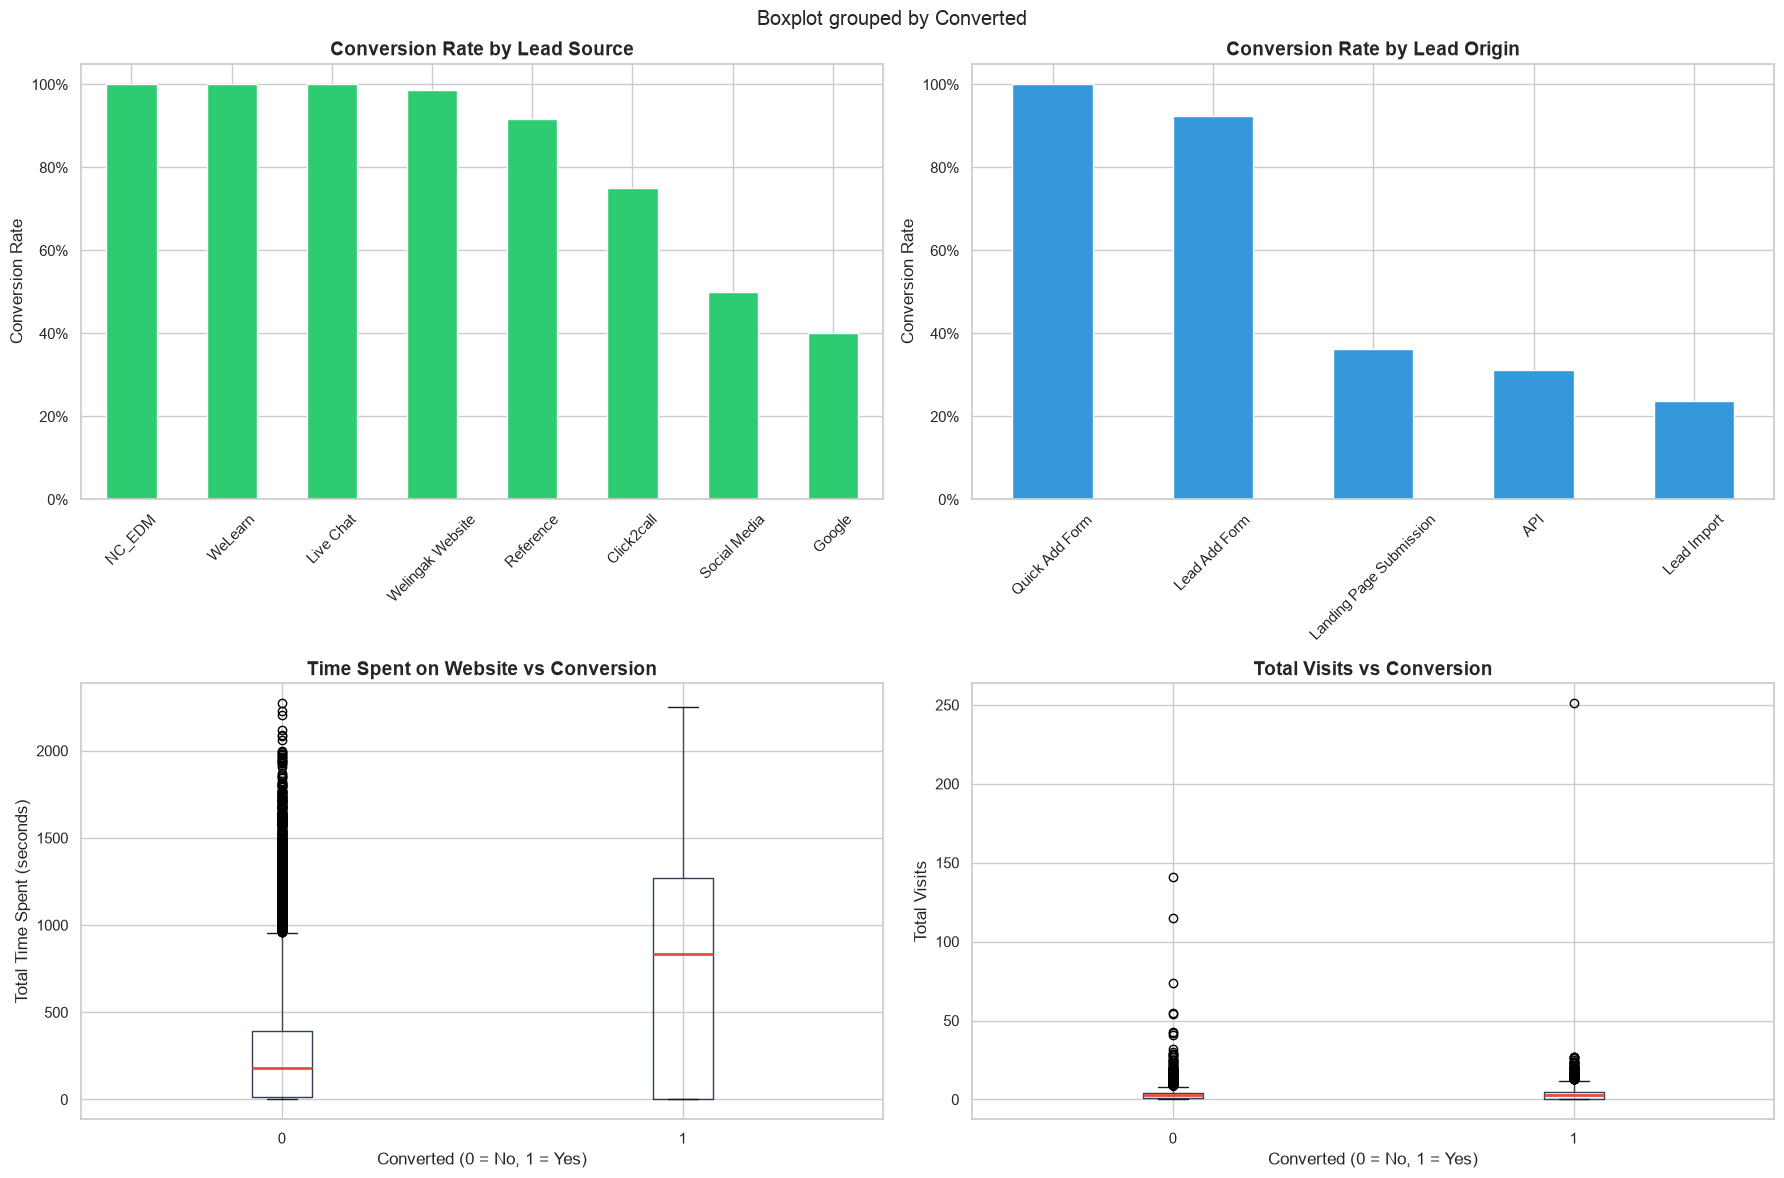

Chart saved.


In [4]:
# ============================================================
# CELL 4 — Conversion Analysis by Key CRM Fields
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Plot 1 - Conversion by Lead Source
lead_source_conv = df.groupby('Lead Source')['Converted'].mean().sort_values(ascending=False).head(8)
lead_source_conv.plot(kind='bar', ax=axes[0,0], color='#2ECC71', edgecolor='white')
axes[0,0].set_title('Conversion Rate by Lead Source', fontsize=14, fontweight='bold')
axes[0,0].set_ylabel('Conversion Rate')
axes[0,0].set_xlabel('')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

# Plot 2 - Conversion by Lead Origin
lead_origin_conv = df.groupby('Lead Origin')['Converted'].mean().sort_values(ascending=False)
lead_origin_conv.plot(kind='bar', ax=axes[0,1], color='#3498DB', edgecolor='white')
axes[0,1].set_title('Conversion Rate by Lead Origin', fontsize=14, fontweight='bold')
axes[0,1].set_ylabel('Conversion Rate')
axes[0,1].set_xlabel('')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

# Plot 3 - Time Spent on Website vs Converted
df.boxplot(column='Total Time Spent on Website', by='Converted', ax=axes[1,0],
           boxprops=dict(color='#2E4057'),
           medianprops=dict(color='#E74C3C', linewidth=2))
axes[1,0].set_title('Time Spent on Website vs Conversion', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Converted (0 = No, 1 = Yes)')
axes[1,0].set_ylabel('Total Time Spent (seconds)')
plt.sca(axes[1,0])
plt.title('Time Spent on Website vs Conversion', fontsize=14, fontweight='bold')

# Plot 4 - Total Visits vs Converted
df.boxplot(column='TotalVisits', by='Converted', ax=axes[1,1],
           boxprops=dict(color='#2E4057'),
           medianprops=dict(color='#E74C3C', linewidth=2))
axes[1,1].set_title('Total Visits vs Conversion', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Converted (0 = No, 1 = Yes)')
axes[1,1].set_ylabel('Total Visits')
plt.sca(axes[1,1])
plt.title('Total Visits vs Conversion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/02_conversion_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

## Correlation Analysis

### What Was Done
- Generated correlation matrix
- Created heatmap
- Analysed feature relationships

### Why This Was Done
- Statistical feature selection
- Multicollinearity detection
- Identify strongest predictors

### What It Showed

#### *Strong Correlations*
- Features with strongest positive relationship

#### *Weak Correlations*
- Features with little predictive value

### Key Dissertation Insight
- Behavioural features outperform demographic features

Numeric columns: ['Lead Number', 'Converted', 'TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit', 'Asymmetrique Activity Score', 'Asymmetrique Profile Score']

=== CORRELATION WITH CONVERTED ===
Converted                      1.000000
Total Time Spent on Website    0.362483
Asymmetrique Profile Score     0.218571
Asymmetrique Activity Score    0.167962
TotalVisits                    0.030395
Lead Number                    0.025157
Page Views Per Visit          -0.003328
Name: Converted, dtype: float64


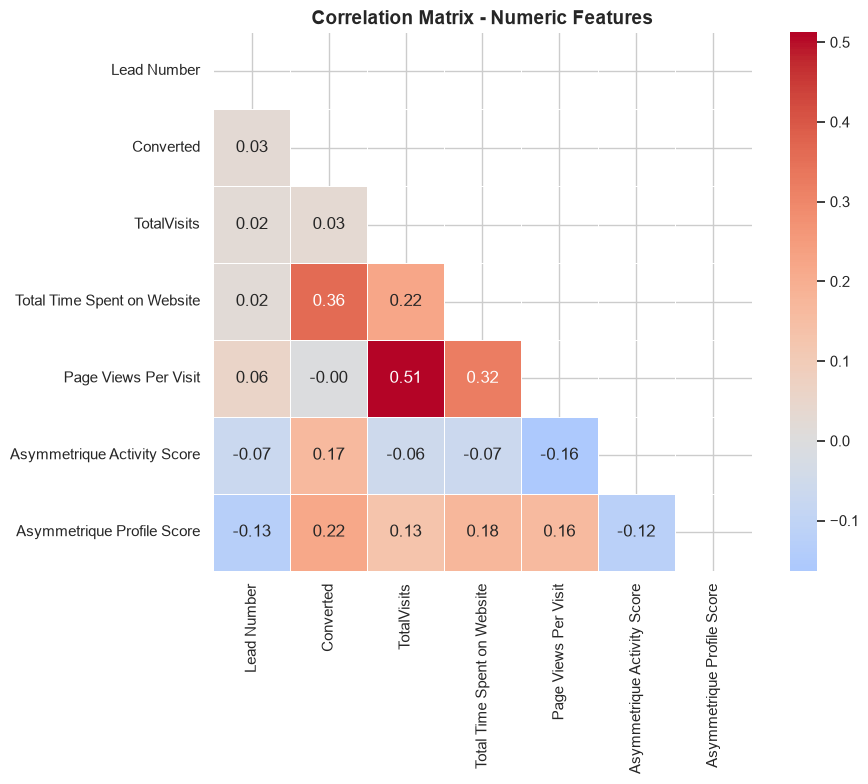

Chart saved.


In [5]:
# ============================================================
# CELL 5 — Correlation Analysis
# ============================================================

# Numeric columns only
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric columns:", numeric_cols)

# Correlation with target
print("\n=== CORRELATION WITH CONVERTED ===")
corr_with_target = df[numeric_cols].corr()['Converted'].sort_values(ascending=False)
print(corr_with_target)

# Heatmap
plt.figure(figsize=(10, 8))
corr_matrix = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)
plt.title('Correlation Matrix - Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/03_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

## Data Cleaning

### What Was Done
- Dropped unnecessary columns
- Performed numeric imputation
- Performed categorical imputation
- Replaced placeholder values
- Conducted final validation

### Why This Was Done
- ML models cannot process missing values
- Remove irrelevant features
- Improve dataset quality

### Cleaning Decisions and Rationale

#### *Dropped Columns*
- ID columns
- High-missing columns
- Near-constant columns

#### *Median Imputation*
- Why median was chosen over mean

#### *Mode Imputation*
- Conservative handling of categorical missing values

#### *Placeholder Replacement*
- Treating `"Select"` as missing data

### Result
- Final retained columns
- Missing values resolved


In [6]:
# ============================================================
# CELL 6 — Data Cleaning
# ============================================================

df_clean = df.copy()

# Step 1 — Drop irrelevant columns
drop_cols = [
    'Prospect ID', 'Lead Number',          # IDs, no predictive value
    'Lead Quality',                          # 51% missing
    'Asymmetrique Activity Index',           # 45% missing
    'Asymmetrique Profile Index',            # 45% missing
    'How did you hear about X Education',    # 24% missing, low value
    'I agree to pay the amount through cheque',  # near constant
    'Get updates on DM Content',             # near constant
    'Update me on Supply Chain Content',     # near constant
    'Receive More Updates About Our Courses' # near constant
]
df_clean.drop(columns=drop_cols, inplace=True)
print(f"After dropping columns: {df_clean.shape}")

# Step 2 — Keep Asymmetrique scores but fill missing with median
for col in ['Asymmetrique Activity Score', 'Asymmetrique Profile Score']:
    median_val = df_clean[col].median()
    df_clean[col].fillna(median_val, inplace=True)
    print(f"Filled {col} with median: {median_val}")

# Step 3 — Fill categorical columns with mode
cat_fill_cols = [
    'Lead Source', 'Lead Origin', 'Last Activity',
    'Specialization', 'What is your current occupation',
    'What matters most to you in choosing a course',
    'Tags', 'Lead Profile', 'City', 'Country',
    'Last Notable Activity'
]
for col in cat_fill_cols:
    if col in df_clean.columns:
        mode_val = df_clean[col].mode()[0]
        df_clean[col].fillna(mode_val, inplace=True)
        print(f"Filled '{col}' with mode: {mode_val}")

# Step 4 — Replace 'Select' values with NaN then mode
# (Kaggle datasets often use 'Select' as a placeholder)
df_clean.replace('Select', np.nan, inplace=True)
for col in df_clean.select_dtypes(include='object').columns:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

# Step 5 — Final check
print(f"\nFinal shape: {df_clean.shape}")
print(f"Missing values remaining: {df_clean.isnull().sum().sum()}")
print(f"\nColumns kept: {df_clean.columns.tolist()}")

After dropping columns: (9240, 27)
Filled Asymmetrique Activity Score with median: 14.0
Filled Asymmetrique Profile Score with median: 16.0
Filled 'Lead Source' with mode: Google
Filled 'Lead Origin' with mode: Landing Page Submission
Filled 'Last Activity' with mode: Email Opened
Filled 'Specialization' with mode: Select
Filled 'What is your current occupation' with mode: Unemployed
Filled 'What matters most to you in choosing a course' with mode: Better Career Prospects
Filled 'Tags' with mode: Will revert after reading the email
Filled 'Lead Profile' with mode: Select
Filled 'City' with mode: Mumbai
Filled 'Country' with mode: India
Filled 'Last Notable Activity' with mode: Modified

Final shape: (9240, 27)
Missing values remaining: 33966

Columns kept: ['Lead Origin', 'Lead Source', 'Do Not Email', 'Do Not Call', 'Converted', 'TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit', 'Last Activity', 'Country', 'Specialization', 'What is your current occupation', 'What m

## Complete Missing Value Resolution

### What Was Done
- Final missing value cleanup
- Updated pandas syntax usage

### Why This Was Done
- Compatibility with latest Python/pandas versions
- Ensure complete data integrity

### Result
- Missing values before and after cleanup

In [7]:
# ============================================================
# CELL 7 — Fix All Remaining Missing Values (Complete Clean)
# ============================================================

# Step 1 — Numeric columns: fill with median
numeric_fill = ['TotalVisits', 'Page Views Per Visit',
                'Asymmetrique Activity Score', 'Asymmetrique Profile Score']

for col in numeric_fill:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)
    print(f"Filled '{col}' with median: {median_val}")

# Step 2 — Binary Yes/No columns: fill with 'No'
binary_cols = [
    'Do Not Email', 'Do Not Call', 'Search', 'Magazine',
    'Newspaper Article', 'X Education Forums', 'Newspaper',
    'Digital Advertisement', 'Through Recommendations',
    'A free copy of Mastering The Interview'
]
for col in binary_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna('No')

# Step 3 — Categorical columns: fill with mode
cat_cols = [
    'Lead Source', 'Last Activity', 'Country', 'Specialization',
    'What is your current occupation',
    'What matters most to you in choosing a course',
    'Tags', 'Lead Profile', 'City', 'Last Notable Activity'
]
for col in cat_cols:
    if col in df_clean.columns:
        mode_val = df_clean[col].mode()[0]
        df_clean[col] = df_clean[col].fillna(mode_val)
        print(f"Filled '{col}' with mode: {mode_val}")

# Step 4 — Replace any remaining 'Select' placeholders
df_clean = df_clean.replace('Select', np.nan)
for col in df_clean.select_dtypes(include='object').columns:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

# Final check
print(f"\nMissing values remaining: {df_clean.isnull().sum().sum()}")
print(f"Final shape: {df_clean.shape}")

Filled 'TotalVisits' with median: 3.0
Filled 'Page Views Per Visit' with median: 2.0
Filled 'Asymmetrique Activity Score' with median: 14.0
Filled 'Asymmetrique Profile Score' with median: 16.0
Filled 'Lead Source' with mode: Google
Filled 'Last Activity' with mode: Email Opened
Filled 'Country' with mode: India
Filled 'Specialization' with mode: Finance Management
Filled 'What is your current occupation' with mode: Unemployed
Filled 'What matters most to you in choosing a course' with mode: Better Career Prospects
Filled 'Tags' with mode: Will revert after reading the email
Filled 'Lead Profile' with mode: Potential Lead
Filled 'City' with mode: Mumbai
Filled 'Last Notable Activity' with mode: Modified

Missing values remaining: 0
Final shape: (9240, 27)


## Feature Engineering

### What Was Done
- Created new engineered features

### Why This Was Done
- Improve predictive capability
- Convert business logic into ML signals
- Enhance behavioural representation

### Features Created

#### *Engagement Level*
- Bucket definitions
- Conversion rate interpretation

#### *High Interaction Flag*
- Binary threshold logic
- Relation to dissertation baseline rule

#### *Lead Source Group*
- Grouping rationale
- Reduction of cardinality

#### *Is Webinar Lead*
- Baseline rule implementation

#### *Engagement Score*
- Composite score logic
- Multi-dimensional engagement representation

### Result
- Feature count increase

In [8]:
# ============================================================
# CELL 8 — Feature Engineering
# ============================================================

df_features = df_clean.copy()

# Feature 1 — Response Time Bucket
# Defined as: time between lead creation and first logged interaction
# Since dataset has no timestamp, we use Total Time Spent as proxy
# and bucket it into engagement levels
def response_time_bucket(time):
    if time == 0:
        return 'No Engagement'
    elif time <= 300:
        return 'Low (0-5 min)'
    elif time <= 900:
        return 'Medium (5-15 min)'
    else:
        return 'High (15+ min)'

df_features['Engagement_Level'] = df_clean['Total Time Spent on Website'].apply(response_time_bucket)
print("Engagement Level distribution:")
print(df_features['Engagement_Level'].value_counts())
print(f"Conversion rate by Engagement Level:")
print(df_features.groupby('Engagement_Level')['Converted'].mean().sort_values(ascending=False))

# Feature 2 — High Interaction Flag
# Based on our baseline Rule 2: leads with 5+ interactions = high priority
df_features['High_Interaction'] = (df_clean['TotalVisits'] >= 5).astype(int)
print(f"\nHigh Interaction leads: {df_features['High_Interaction'].sum()}")
print(f"Conversion rate - High Interaction: {df_features[df_features['High_Interaction']==1]['Converted'].mean():.2%}")
print(f"Conversion rate - Low Interaction: {df_features[df_features['High_Interaction']==0]['Converted'].mean():.2%}")

# Feature 3 — Lead Source Group
# Group similar sources to reduce cardinality
def group_lead_source(source):
    if source in ['Google', 'Organic Search', 'Bing']:
        return 'Search Engine'
    elif source in ['Direct Traffic', 'NC_EDM']:
        return 'Direct'
    elif source in ['Olark Chat', 'Live Chat']:
        return 'Chat'
    elif source in ['WeLearn', 'Welingak Website']:
        return 'Partner'
    elif source in ['Reference', 'Through Recommendations']:
        return 'Referral'
    elif source in ['Social Media', 'Facebook', 'youtube']:
        return 'Social'
    else:
        return 'Other'

df_features['Lead_Source_Group'] = df_clean['Lead Source'].apply(group_lead_source)
print("\nLead Source Group distribution:")
print(df_features['Lead_Source_Group'].value_counts())
print("\nConversion rate by Lead Source Group:")
print(df_features.groupby('Lead_Source_Group')['Converted'].mean().sort_values(ascending=False))

# Feature 4 — Is Webinar Lead (Baseline Rule 1)
df_features['Is_Webinar_Lead'] = (df_clean['Lead Source'] == 'Webinar').astype(int)
print(f"\nWebinar leads found: {df_features['Is_Webinar_Lead'].sum()}")

# Feature 5 — Engagement Score (composite)
df_features['Engagement_Score'] = (
    df_clean['Total Time Spent on Website'] * 0.5 +
    df_clean['TotalVisits'] * 10 +
    df_clean['Page Views Per Visit'] * 5
)
print(f"\nEngagement Score stats:")
print(df_features['Engagement_Score'].describe())

print(f"\nFinal feature set shape: {df_features.shape}")

Engagement Level distribution:
Engagement_Level
Low (0-5 min)        2856
High (15+ min)       2392
No Engagement        2193
Medium (5-15 min)    1799
Name: count, dtype: int64
Conversion rate by Engagement Level:
Engagement_Level
High (15+ min)       0.698161
No Engagement        0.417693
Medium (5-15 min)    0.319622
Low (0-5 min)        0.140056
Name: Converted, dtype: float64

High Interaction leads: 2413
Conversion rate - High Interaction: 42.02%
Conversion rate - Low Interaction: 37.31%

Lead Source Group distribution:
Lead_Source_Group
Search Engine    4058
Direct           2544
Chat             1757
Referral          534
Other             147
Partner           143
Social             57
Name: count, dtype: int64

Conversion rate by Lead Source Group:
Lead_Source_Group
Partner          0.986014
Referral         0.917603
Search Engine    0.397240
Direct           0.321934
Chat             0.256118
Social           0.245614
Other            0.238095
Name: Converted, dtype: float64

## Categorical Encoding

### What Was Done
- Converted categorical variables into numerical format

### Why This Was Done
- Machine learning requires numeric input
- Different encoding methods for different feature types

### Encoding Decisions

#### *Binary Encoding*
- Yes/No mapping

#### *Ordinal Encoding*
- Ordered category representation

#### *One-Hot Encoding*
- Dummy variable creation
- Avoiding dummy variable trap

### Result
- Expansion in feature count after encoding

In [9]:
# ============================================================
# CELL 9 — Encoding Categorical Variables
# ============================================================

from sklearn.preprocessing import LabelEncoder

df_encoded = df_features.copy()

# Step 1 — Binary Yes/No columns: convert to 0/1
binary_cols = [
    'Do Not Email', 'Do Not Call', 'Search', 'Magazine',
    'Newspaper Article', 'X Education Forums', 'Newspaper',
    'Digital Advertisement', 'Through Recommendations',
    'A free copy of Mastering The Interview'
]
for col in binary_cols:
    df_encoded[col] = df_encoded[col].map({'Yes': 1, 'No': 0})
    
print("Binary columns encoded.")

# Step 2 — Engagement Level: ordinal encoding (order matters)
engagement_order = {
    'No Engagement': 0,
    'Low (0-5 min)': 1,
    'Medium (5-15 min)': 2,
    'High (15+ min)': 3
}
df_encoded['Engagement_Level'] = df_encoded['Engagement_Level'].map(engagement_order)
print("Engagement Level encoded.")

# Step 3 — One-hot encode remaining categorical columns
ohe_cols = [
    'Lead Origin', 'Lead Source', 'Last Activity', 'Country',
    'Specialization', 'What is your current occupation',
    'What matters most to you in choosing a course',
    'Tags', 'Lead Profile', 'City', 'Lead_Source_Group',
    'Last Notable Activity'
]

df_encoded = pd.get_dummies(df_encoded, columns=ohe_cols, drop_first=True)
print(f"After one-hot encoding shape: {df_encoded.shape}")

# Step 4 — Final check
print(f"\nData types remaining:")
print(df_encoded.dtypes.value_counts())
print(f"\nAny missing values: {df_encoded.isnull().sum().sum()}")
print(f"\nTarget distribution check:")
print(df_encoded['Converted'].value_counts())

Binary columns encoded.
Engagement Level encoded.
After one-hot encoding shape: (9240, 176)

Data types remaining:
bool       156
int64       15
float64      5
Name: count, dtype: int64

Any missing values: 0

Target distribution check:
Converted
0    5679
1    3561
Name: count, dtype: int64


## Train/Test Split and SMOTE

### What Was Done
- Split dataset into train/test sets
- Applied SMOTE
- Applied feature scaling

### Why This Was Done

#### *Train-Test Split*
- Industry-standard ratio
- Stratification importance

#### *SMOTE*
- Handling class imbalance
- Why applied only to training data

#### *StandardScaler*
- Feature normalisation
- Importance for scale-sensitive algorithms

### Result
- Balanced training dataset
- Preserved real-world test distribution
- Final dataset ready for modelling

In [10]:
# ============================================================
# CELL 10 — Train/Test Split & SMOTE
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Step 1 — Separate features and target
X = df_encoded.drop(columns=['Converted'])
y = df_encoded['Converted']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nClass distribution before SMOTE:")
print(y.value_counts())
print(f"Conversion rate: {y.mean():.2%}")

# Step 2 — Train/Test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTraining set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nClass distribution in training set:")
print(y_train.value_counts())

# Step 3 — Apply SMOTE on training set only
# IMPORTANT: SMOTE only on train, never on test
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE:")
print(f"Training set shape: {X_train_smote.shape}")
print(f"Class distribution after SMOTE:")
print(pd.Series(y_train_smote).value_counts())

# Step 4 — Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

print(f"\nScaling complete.")
print(f"Ready for modelling!")

# Save processed data info
print(f"\n=== FINAL SUMMARY ===")
print(f"Training samples (after SMOTE): {X_train_smote.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Number of features: {X_train_smote.shape[1]}")

Features shape: (9240, 175)
Target shape: (9240,)

Class distribution before SMOTE:
Converted
0    5679
1    3561
Name: count, dtype: int64
Conversion rate: 38.54%

Training set: (7392, 175)
Test set: (1848, 175)

Class distribution in training set:
Converted
0    4543
1    2849
Name: count, dtype: int64

After SMOTE:
Training set shape: (9086, 175)
Class distribution after SMOTE:
Converted
1    4543
0    4543
Name: count, dtype: int64

Scaling complete.
Ready for modelling!

=== FINAL SUMMARY ===
Training samples (after SMOTE): 9086
Test samples: 1848
Number of features: 175


## Summary of Phase 2 and Phase 3 Outcomes

| Metric | Value |
|---|---|
| Original Dataset | 9,240 rows, 37 columns |
| After Data Cleaning | 9,240 rows, 27 columns |
| After Feature Engineering | 9,240 rows, 32 columns |
| After Encoding | 9,240 rows, 176 columns |
| Training Set (Post SMOTE) | 9,086 samples, balanced 50:50 |
| Test Set | 1,848 samples with original class distribution |
| Missing Values | 0 |
| Key Finding | Time spent on website and lead source emerged as the strongest predictors of conversion |

## Overall Conclusion

The dataset was successfully preprocessed through cleaning, feature engineering, encoding, and class balancing techniques. Missing values and irrelevant features were effectively handled, resulting in a refined and machine learning ready dataset. SMOTE was applied to address class imbalance, ensuring improved model learning and fair prediction capability.

The analysis revealed that user engagement metrics, particularly time spent on the website, along with lead source information, play a major role in predicting customer conversion.

The final processed dataset is well structured and optimized for building reliable predictive models for lead conversion analysis.